# Nigeria Incidents Project

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("incidents.csv")
df.head()

,Identifier,Title,Start date,End date,Number of deaths
0,IBD031681,"Food Poisoning, Imo",2025-04-18,2025-04-18,1
1,IBD032064,"Gunmen Kill Man, Benue",2025-03-31,2025-03-31,1
2,IBD032058,"Auto Crash, Lagos",2025-03-31,2025-03-31,1
3,IBD032066,"Stray Bullets, Sokoto",2025-03-31,2025-03-31,1
4,IBD032062,"Lightening Kills Herder, Kaduna",2025-03-30,2025-03-30,1


In [3]:
df.shape

(7500, 5)

In [4]:
df.columns

Index(['Identifier', 'Title', 'Start date', 'End date', 'Number of deaths'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Identifier        7500 non-null   object
 1   Title             7500 non-null   object
 2   Start date        7500 non-null   object
 3   End date          7500 non-null   object
 4   Number of deaths  7500 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 293.1+ KB


In [6]:
df.describe()

,Number of deaths
count,7500.000000
mean,4.713733
std,11.160412
min,1.000000
25%,1.000000
50%,1.000000
75%,4.000000
max,244.000000


# Data Cleaning

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.columns.tolist()

['Identifier', 'Title', 'Start date', 'End date', 'Number of deaths']

In [9]:
df.isnull().sum()

Identifier          0
Title               0
Start date          0
End date            0
Number of deaths    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(15)

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

### Convert start date

In [13]:
df ["Start date"] = pd.to_datetime(df["Start date"], errors="coerce")


In [14]:
df["Identifier"] = df["Identifier"].astype(str).str.strip()

df["Title"] = df["Title"].astype(str).str.strip()



In [15]:
print( df["Start date"].dtype)

datetime64[ns]


### Convert End date

In [16]:
df ["End date"] = pd.to_datetime(df["End date"], errors="coerce")


In [17]:
print( df["End date"].dtype)

datetime64[ns]


### Convert number of deaths

In [18]:
df["Number of deaths"] = pd.to_numeric(df["Number of deaths"], errors="coerce")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7485 entries, 0 to 7499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Identifier        7485 non-null   object        
 1   Title             7485 non-null   object        
 2   Start date        7484 non-null   datetime64[ns]
 3   End date          7484 non-null   datetime64[ns]
 4   Number of deaths  7485 non-null   int64         
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 350.9+ KB


In [20]:
df.head()

,Identifier,Title,Start date,End date,Number of deaths
0,IBD031681,"Food Poisoning, Imo",2025-04-18,2025-04-18,1
1,IBD032064,"Gunmen Kill Man, Benue",2025-03-31,2025-03-31,1
2,IBD032058,"Auto Crash, Lagos",2025-03-31,2025-03-31,1
3,IBD032066,"Stray Bullets, Sokoto",2025-03-31,2025-03-31,1
4,IBD032062,"Lightening Kills Herder, Kaduna",2025-03-30,2025-03-30,1


In [21]:
df.isnull().sum()

Identifier          0
Title               0
Start date          1
End date            1
Number of deaths    0
dtype: int64

In [22]:
df[df["Start date"].isnull() | df["End date"].isnull()]

,Identifier,Title,Start date,End date,Number of deaths
5842,IBD028043,"Police Kill Kidnapper, Yobe",NaT,NaT,1


In [23]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7485 entries, 0 to 7499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Identifier        7485 non-null   object        
 1   Title             7485 non-null   object        
 2   Start date        7484 non-null   datetime64[ns]
 3   End date          7484 non-null   datetime64[ns]
 4   Number of deaths  7485 non-null   int64         
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 350.9+ KB


### Create Year

In [24]:
df["Year"] = df["Start date"].dt.year

In [25]:
df[["Start date", "Year"]].head()

,Start date,Year
0,2025-04-18,2025.0
1,2025-03-31,2025.0
2,2025-03-31,2025.0
3,2025-03-31,2025.0
4,2025-03-30,2025.0


### Create Month and Month name

In [26]:
df["Month"] = df["Start date"].dt.month

In [27]:
df["Month Name"] = df["Start date"].dt.month_name()

### Create day of week

In [28]:
df["Day of Week"] = df["Start date"].dt.day_name()

In [29]:
df.head()

,Identifier,Title,Start date,End date,Number of deaths,Year,Month,Month Name,Day of Week
0,IBD031681,"Food Poisoning, Imo",2025-04-18,2025-04-18,1,2025.0,4.0,April,Friday
1,IBD032064,"Gunmen Kill Man, Benue",2025-03-31,2025-03-31,1,2025.0,3.0,March,Monday
2,IBD032058,"Auto Crash, Lagos",2025-03-31,2025-03-31,1,2025.0,3.0,March,Monday
3,IBD032066,"Stray Bullets, Sokoto",2025-03-31,2025-03-31,1,2025.0,3.0,March,Monday
4,IBD032062,"Lightening Kills Herder, Kaduna",2025-03-30,2025-03-30,1,2025.0,3.0,March,Sunday


### Extract state and state extraction function

In [30]:
states = [
    "Abia",
    "Adamawa",
    "Akwa Ibom",
    "Anambra",
    "Bauchi",
    "Bayelsa",
    "Benue",
    "Borno",
    "Cross River",
    "Delta",
    "Ebonyi",
    "Edo",
    "Ekiti",
    "Enugu",
    "Gombe",
    "Imo",
    "Jigawa",
    "Kaduna",
    "Kano",
    "Katsina",
    "Kebbi",
    "Kogi",
    "Kwara",
    "Lagos",
    "Nasarawa",
    "Niger",
    "Ogun",
    "Ondo",
    "Osun",
    "Oyo",
    "Plateau",
    "Rivers",
    "Sokoto",
    "Taraba",
    "Yobe",
    "Zamfara",
    "FCT",
    "Abuja"
]


In [31]:
def extract_state(title):
    for state in states:
        if state.lower() in str(title).lower():
            return state
    return "Unknown"

 #### create state column

In [32]:
df["State"] = df["Title"].apply(extract_state)

df[["Title", "State"]].head(10)

,Title,State
0,"Food Poisoning, Imo",Imo
1,"Gunmen Kill Man, Benue",Benue
2,"Auto Crash, Lagos",Lagos
3,"Stray Bullets, Sokoto",Sokoto
4,"Lightening Kills Herder, Kaduna",Kaduna
5,"Auto Crash, Katsina",Katsina
6,"Sallah Day Celebration Clash, Plateau",Plateau
7,"Auto Crash, Abia",Abia
8,"Gas Explosion, Delta",Delta
9,"Auto Crash, Ogun",Ogun


In [33]:
df.columns

Index(['Identifier', 'Title', 'Start date', 'End date', 'Number of deaths',
       'Year', 'Month', 'Month Name', 'Day of Week', 'State'],
      dtype='object')

In [34]:
def extract_state(title):
    for state in states:
        if state.lower() in str(title).lower():
            return state
    return "Unknown"

In [35]:
df["State"] = df["Title"].apply(extract_state)

df[["Title", "State"]].head(10)

,Title,State
0,"Food Poisoning, Imo",Imo
1,"Gunmen Kill Man, Benue",Benue
2,"Auto Crash, Lagos",Lagos
3,"Stray Bullets, Sokoto",Sokoto
4,"Lightening Kills Herder, Kaduna",Kaduna
5,"Auto Crash, Katsina",Katsina
6,"Sallah Day Celebration Clash, Plateau",Plateau
7,"Auto Crash, Abia",Abia
8,"Gas Explosion, Delta",Delta
9,"Auto Crash, Ogun",Ogun


## Create Incident type function and column

In [36]:
def extract_incident_type(title):
    title = str(title).lower()

    if "auto crash" in title or "car crash" in title:
        return "Auto Crash"
    elif "fire" in title:
        return "Fire"
    elif "flood" in title:
        return "Flood"
    elif "robbery" in title:
        return "Robbery"
    elif "accident" in title:
        return "Accident"
    else:
        return "Other"

In [37]:
df["Incident Type"] = df["Title"].apply(extract_incident_type)
df[["Title", "Incident Type"]].head(20)

,Title,Incident Type
0,"Food Poisoning, Imo",Other
1,"Gunmen Kill Man, Benue",Other
2,"Auto Crash, Lagos",Auto Crash
3,"Stray Bullets, Sokoto",Other
4,"Lightening Kills Herder, Kaduna",Other
5,"Auto Crash, Katsina",Auto Crash
6,"Sallah Day Celebration Clash, Plateau",Other
7,"Auto Crash, Abia",Auto Crash
8,"Gas Explosion, Delta",Other
9,"Auto Crash, Ogun",Auto Crash


## Incident duration

In [38]:
df["Incident Duration (days)"] = (
    df["End date"] - df["Start date"]
).dt.days
df["Incident Duration (days)"].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Incident Duration (days), dtype: float64

In [39]:
negative_duration = (
    df["Incident Duration (days)"] < 0
).sum()
print(
    "Number of Incidents with negative duration:",
    negative_duration
)

Number of Incidents with negative duration: 7


In [40]:
df.loc[
    df["Incident Duration (days)"] < 0,
    "Incident Duration (days)"
    ] = 0

In [41]:
missing_values = df.isnull().sum

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
<bound method DataFrame.sum of       Identifier  Title  Start date  End date  Number of deaths   Year  Month  \
0          False  False       False     False             False  False  False   
1          False  False       False     False             False  False  False   
2          False  False       False     False             False  False  False   
3          False  False       False     False             False  False  False   
4          False  False       False     False             False  False  False   
...          ...    ...         ...       ...               ...    ...    ...   
7495       False  False       False     False             False  False  False   
7496       False  False       False     False             False  False  False   
7497       False  False       False     False             False  False  False   
7498       False  False       False     False             False  False  False   
7499       False  False       False     False  

In [42]:
df = df.dropna()
print("Dataset shape after removing missing values:")
print(df.shape)

Dataset shape after removing missing values:
(7484, 12)


In [43]:
print(df.isnull().sum())

Identifier                  0
Title                       0
Start date                  0
End date                    0
Number of deaths            0
Year                        0
Month                       0
Month Name                  0
Day of Week                 0
State                       0
Incident Type               0
Incident Duration (days)    0
dtype: int64


## Final Data Cleaning check

In [44]:
print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)

Number of duplicate rows: 0


In [45]:
print("Final dataset shape:")
print(df.shape)

Final dataset shape:
(7484, 12)


In [46]:
print("Final columns:")
for column in df.columns:
    print(column)

Final columns:
Identifier
Title
Start date
End date
Number of deaths
Year
Month
Month Name
Day of Week
State
Incident Type
Incident Duration (days)


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7484 entries, 0 to 7499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Identifier                7484 non-null   object        
 1   Title                     7484 non-null   object        
 2   Start date                7484 non-null   datetime64[ns]
 3   End date                  7484 non-null   datetime64[ns]
 4   Number of deaths          7484 non-null   int64         
 5   Year                      7484 non-null   float64       
 6   Month                     7484 non-null   float64       
 7   Month Name                7484 non-null   object        
 8   Day of Week               7484 non-null   object        
 9   State                     7484 non-null   object        
 10  Incident Type             7484 non-null   object        
 11  Incident Duration (days)  7484 non-null   float64       
dtypes: datetime64[ns](2), flo

## Research Questions analysis

#### 1. Calculate the total number of incidents.

In [48]:
total_incidents = len(df)
print("Total number of incidents:",
      total_incidents)

Total number of incidents: 7484


Calculate the total number of deaths recorded

In [49]:
total_deaths = df["Number of deaths"].sum()
print("Total number of deaths:",
      total_deaths)

Total number of deaths: 35267


Count incidents recorded in each year

In [50]:
incidents_by_year = (
    df["Year"]
    .value_counts()
    .sort_index()
)
print(incidents_by_year)

Year
2022.0    1653
2023.0    2604
2024.0    2610
2025.0     617
Name: count, dtype: int64


#### 2. Count incidents in each state

In [51]:
incidents_by_state = (
    df["State"]
    .value_counts()
)
print(
    incidents_by_state.head(10)
)

State
Lagos      624
Ogun       484
Kaduna     461
Delta      352
Benue      328
Niger      326
Borno      315
FCT        312
Anambra    281
Plateau    268
Name: count, dtype: int64


#### 3. Calculate the total deaths for each state.

In [52]:
deaths_by_state = (
    df.groupby("State")["Number of deaths"]
    .sum()
    .sort_values(ascending=False)
)
print(
    deaths_by_state.head(10)
)

State
Borno      5738
Kaduna     2567
Zamfara    2531
Niger      2468
Benue      2101
Katsina    2076
Plateau    1495
Lagos      1056
Ogun        977
Anambra     894
Name: Number of deaths, dtype: int64


#### 4. Count the number of incidents for each incident type

In [53]:
incidents_by_type = (
    df["Incident Type"]
    .value_counts()
)
print(
    incidents_by_type.head(10)
)

Incident Type
Other         6196
Auto Crash    1047
Flood          187
Accident        20
Fire            17
Robbery         17
Name: count, dtype: int64


#### 5. Calculate total deaths for each incident type

In [54]:
deaths_by_type = (
    df.groupby("Incident Type")["Number of deaths"]
    .sum()
    .sort_values(ascending=False)
)
print(
    deaths_by_type.head(10)
)

Incident Type
Other         29411
Auto Crash     4606
Flood          1007
Fire             95
Accident         93
Robbery          55
Name: Number of deaths, dtype: int64


#### 6. Count the number of incidents recorded in each month

In [55]:
incidents_by_month = (
    df["Month Name"]
    .value_counts()
)
print(incidents_by_month)

Month Name
August       733
September    727
July         683
October      679
January      676
March        663
November     629
June         570
December     560
February     553
April        539
May          472
Name: count, dtype: int64


#### 7. Count incidents recorded on each day.

In [56]:
incidents_by_day = (
    df["Day of Week"]
    .value_counts()
)
print(incidents_by_day)

Day of Week
Sunday       1236
Saturday     1190
Monday       1093
Tuesday      1083
Wednesday    1025
Friday        945
Thursday      912
Name: count, dtype: int64


#### 8. Calculate the average duration of incidents

In [57]:
average_duration = (
    df["Incident Duration (days)"].mean()
   
)
print(
    "Average incident duration:",
    round(average_duration, 2),
)

Average incident duration: 0.71


#### 9. Calculate the average incident duration for each state.

In [58]:
average_duration_by_state = (
    df.groupby("State")["Incident Duration (days)"]
    .mean()
    .sort_values(ascending=False)
)
print(
    average_duration_by_state.head(10)
)

State
Unknown    8.571429
Yobe       4.134328
Bayelsa    3.094118
Jigawa     2.634409
Sokoto     2.597938
Taraba     2.564356
Kano       2.156977
Ebonyi     1.820896
Rivers     1.613169
Oyo        1.414773
Name: Incident Duration (days), dtype: float64


#### 10. Group the data by year and calculate:
* Number of incidents
* Total number of deaths

In [59]:
year_analysis = (
    df.groupby("Year")
    .agg(
    Number_of_incidents=("Identifier", "count"),
        Total_Deaths=("Number of deaths", "sum")
        )
        .reset_index()
    )
print(year_analysis)


     Year  Number_of_incidents  Total_Deaths
0  2022.0                 1653          8336
1  2023.0                 2604         11889
2  2024.0                 2610         12236
3  2025.0                  617          2806


#### Correlationship between incidents and deaths

In [60]:


# Count the number of incidents for each year
number_of_incidents = df.groupby("Year")["Identifier"].count()

# Calculate the total number of deaths for each year
total_deaths = df.groupby("Year")["Number of deaths"].sum()

# Combine both results into one DataFrame
correlation_data = pd.DataFrame({
    "Number_of_Incidents": number_of_incidents,
    "Total_Deaths": total_deaths
})

# Calculate the correlation
correlation = correlation_data["Number_of_Incidents"].corr(
    correlation_data["Total_Deaths"]
)

print(correlation_data)
print()
print("Correlation between incidents and deaths:", correlation)

        Number_of_Incidents  Total_Deaths
Year                                     
2022.0                 1653          8336
2023.0                 2604         11889
2024.0                 2610         12236
2025.0                  617          2806

Correlation between incidents and deaths: 0.9963290486738302


## Data Visualization

### Incidents by year

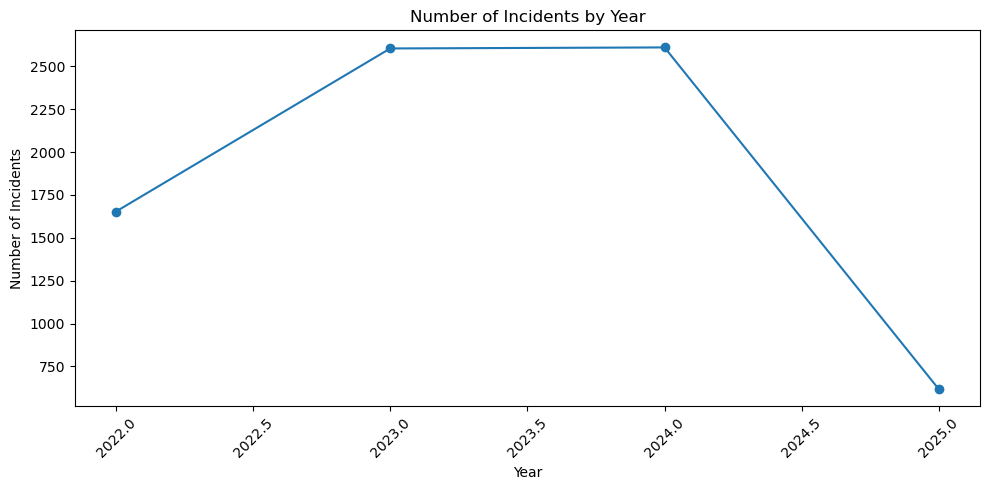

In [61]:
plt.figure(figsize=(10,5))

plt.plot(
    incidents_by_year.index,
    incidents_by_year.values,
    marker="o"
)
plt.title("Number of Incidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Tota deaths by year

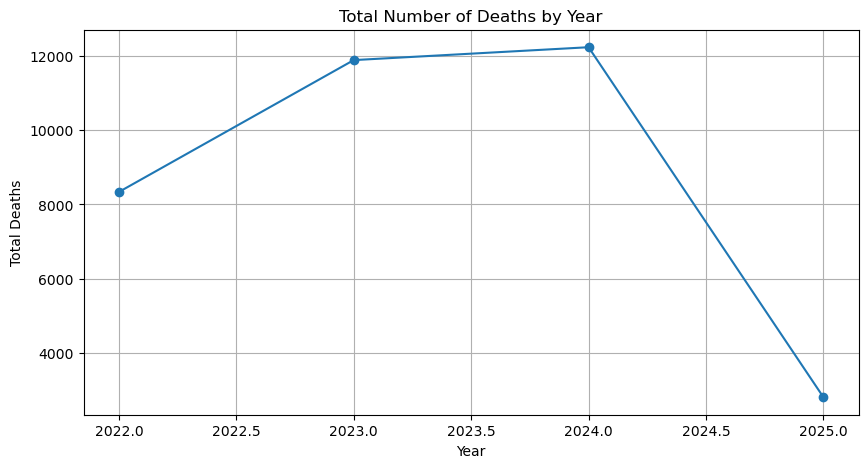

In [70]:
deaths_by_year = (
    df.groupby("Year")["Number of deaths"]
    .sum()
)

plt.figure(figsize=(10,5))

plt.plot(
    deaths_by_year.index,
    deaths_by_year.values,
    marker="o"
)

plt.title("Total Number of Deaths by Year")
plt.xlabel("Year")
plt.ylabel("Total Deaths")

plt.grid(True)
plt.show()

### Top 10 states by number of incidents

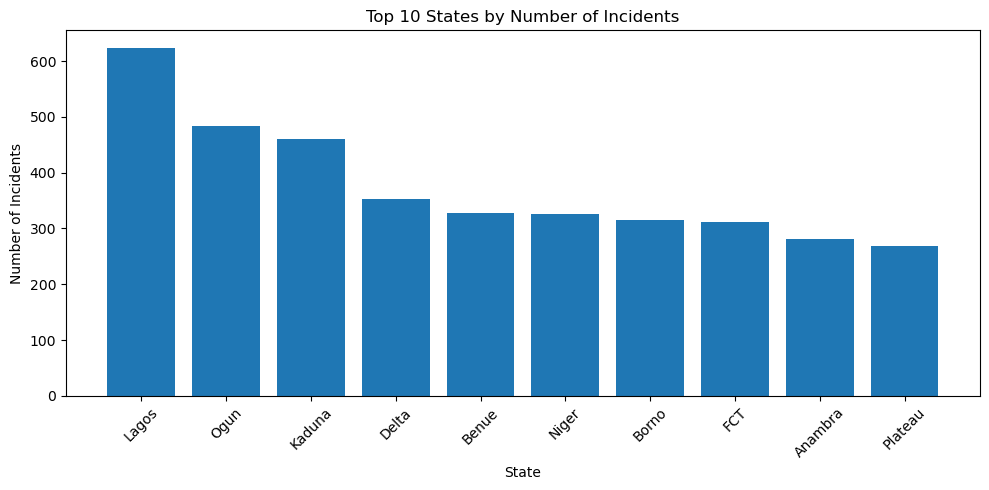

In [62]:
top_states = incidents_by_state.head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_states.index,
    top_states.values
)

plt.title("Top 10 States by Number of Incidents")
plt.xlabel("State")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Top 10 Incidents Type 

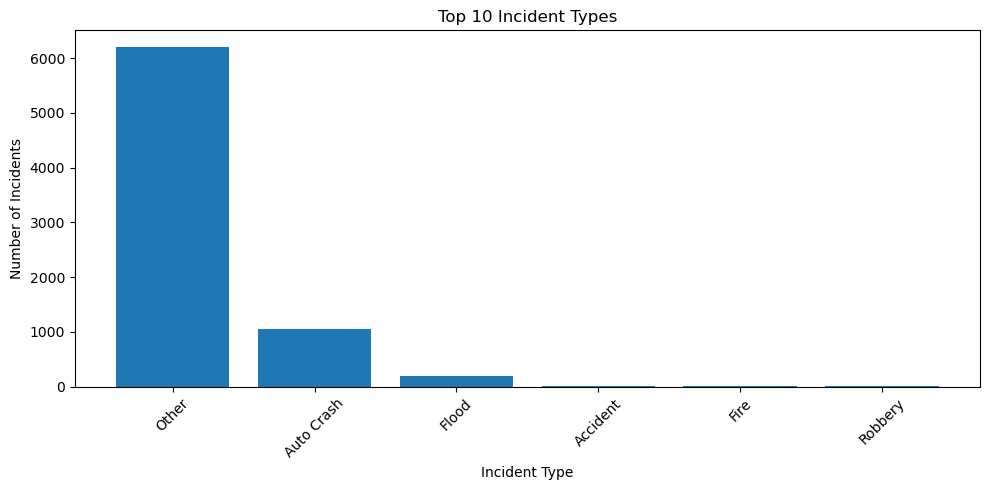

In [63]:
top_incident_types = incidents_by_type.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_incident_types.index,
    top_incident_types.values
)
plt.title("Top 10 Incident Types")
plt.xlabel("Incident Type")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Distribution of number of deaths

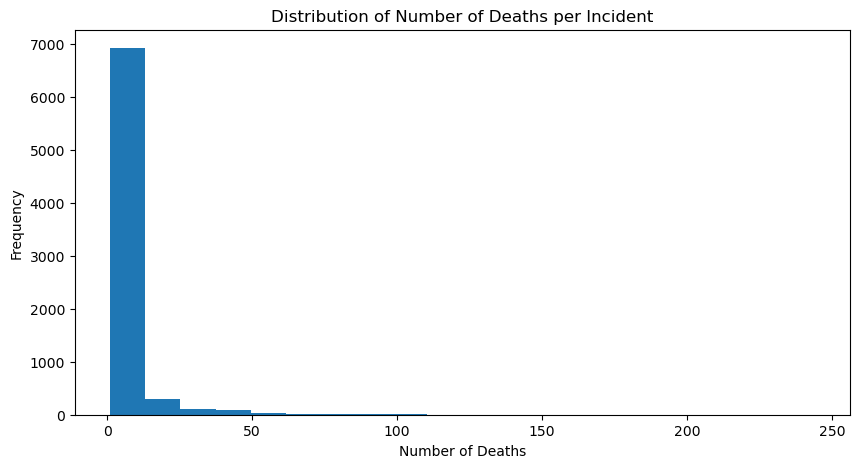

In [73]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Number of deaths"],
    bins=20
    )
plt.title("Distribution of Number of Deaths per Incident")
plt.xlabel("Number of Deaths")
plt.ylabel("Frequency")

plt.show()

### Deaths by state

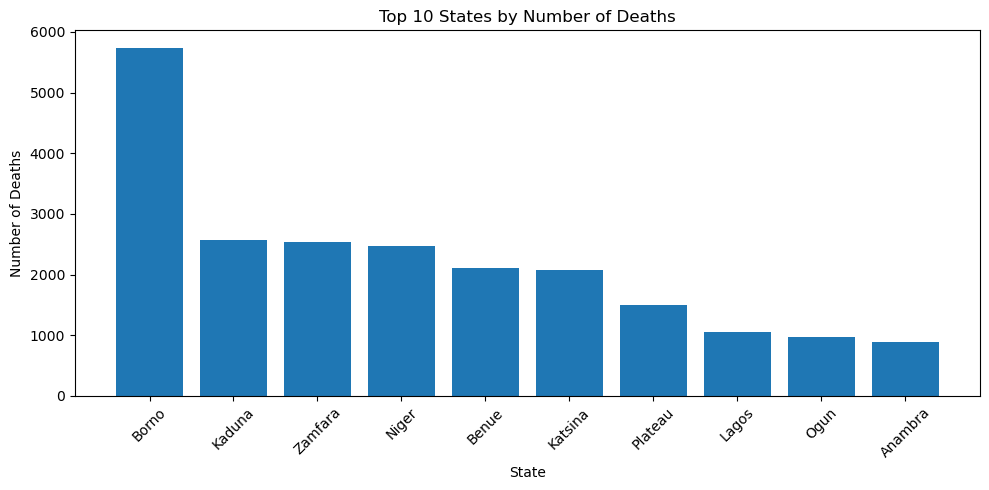

In [64]:
top_death_states = deaths_by_state.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_death_states.index,
    top_death_states.values
)
plt.title("Top 10 States by Number of Deaths")
plt.xlabel("State")
plt.ylabel("Number of Deaths")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Incidents by Month

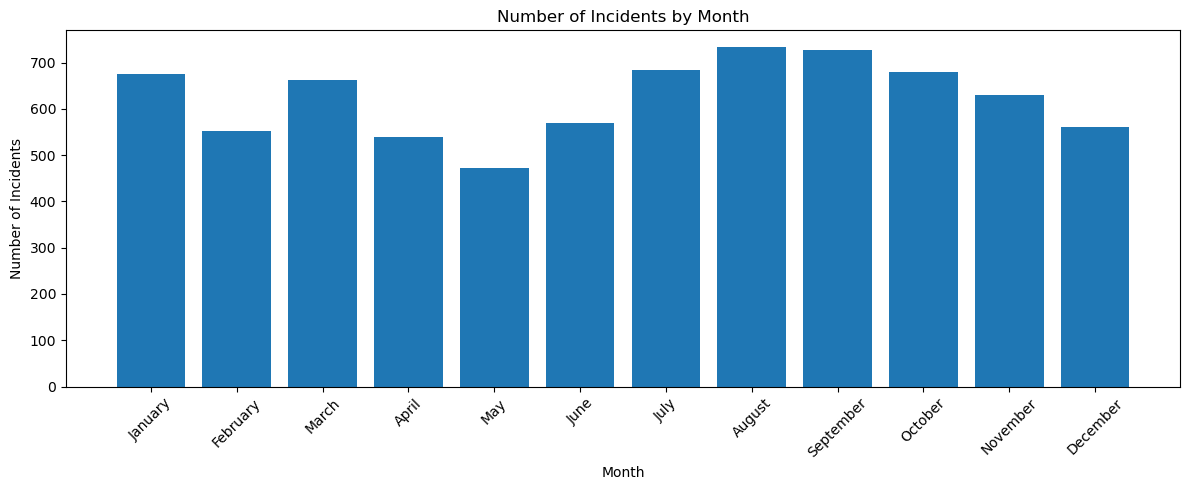

In [65]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_ordered = (
    df["Month Name"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(12, 5))

plt.bar(
    monthly_ordered.index,
    monthly_ordered.values
)

plt.title("Number of Incidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Incidents by day of week 

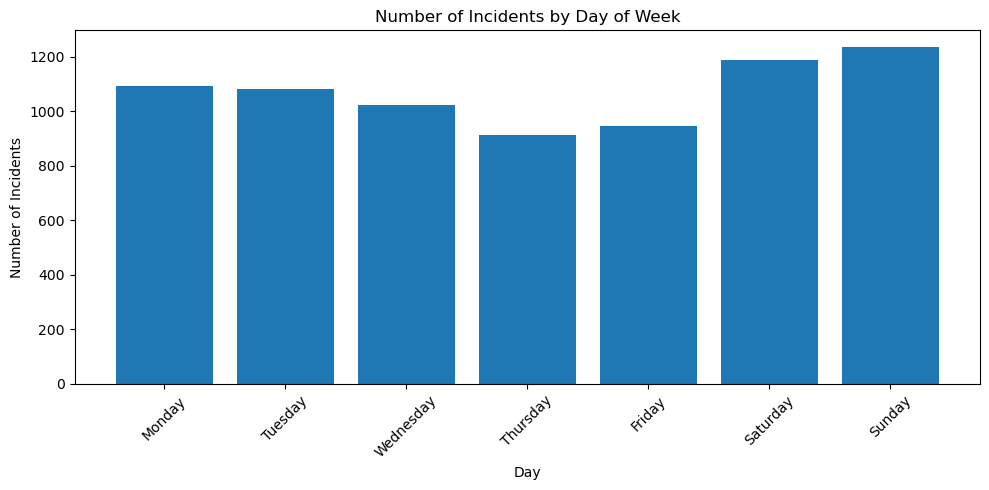

In [66]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_ordered = (
    df["Day of Week"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

plt.bar(
    day_ordered.index,
    day_ordered.values
)

plt.title("Number of Incidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Incident vs death

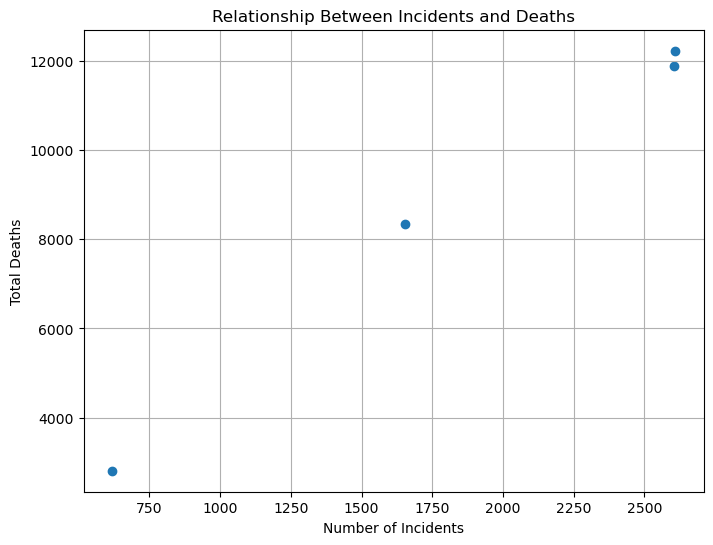

In [68]:
year_analysis = (
    df.groupby("Year")
    .agg(
        Number_of_Incidents=("Identifier", "count"),
        Total_Deaths=("Number of deaths", "sum")
    )
    .reset_index()
)
plt.figure(figsize=(8, 6))

plt.scatter(
    year_analysis["Number_of_Incidents"],
    year_analysis["Total_Deaths"]
)

plt.title("Relationship Between Incidents and Deaths")
plt.xlabel("Number of Incidents")
plt.ylabel("Total Deaths")

plt.grid(True)

plt.show()

### Incident Duration

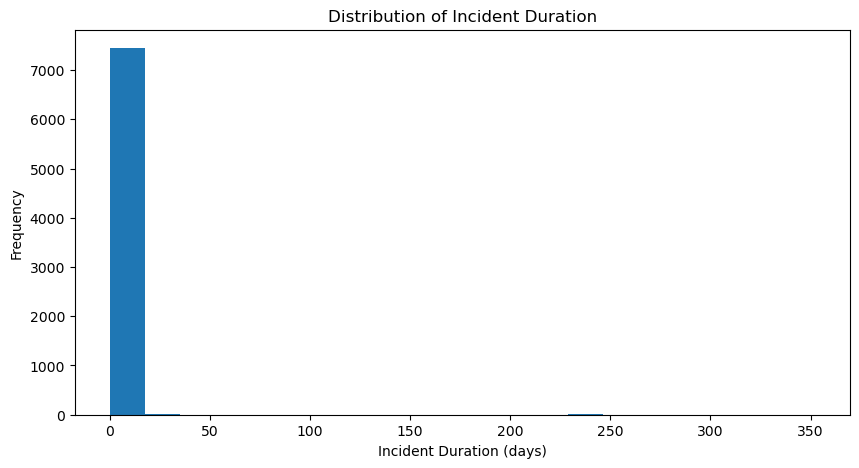

In [75]:
plt.figure(figsize=(10,5))
plt.hist(
    df["Incident Duration (days)"],
    bins=20
)
plt.title("Distribution of Incident Duration")
plt.xlabel("Incident Duration (days)")
plt.ylabel("Frequency")

plt.show()

### Correlation heatmap

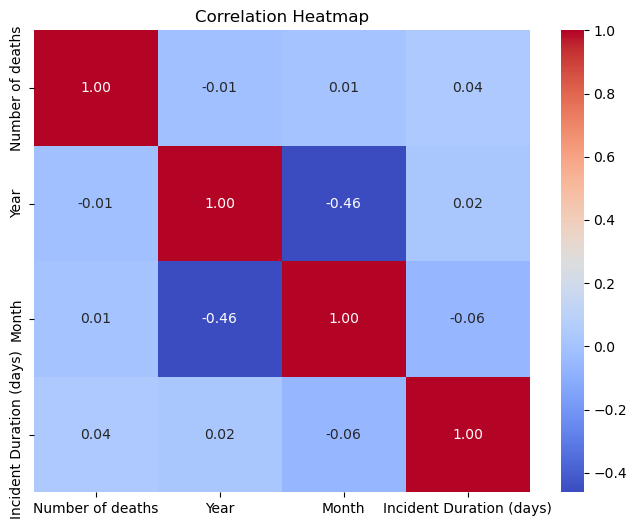

In [78]:
correlation_data = df[
    [
        "Number of deaths",
        "Year",
        "Month",
        "Incident Duration (days)"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_data,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")

plt.show()

## Final checks and preview

In [77]:
df.head(10)

,Identifier,Title,Start date,End date,Number of deaths,Year,Month,Month Name,Day of Week,State,Incident Type,Incident Duration (days)
0,IBD031681,"Food Poisoning, Imo",2025-04-18,2025-04-18,1,2025.0,4.0,April,Friday,Imo,Other,0.0
1,IBD032064,"Gunmen Kill Man, Benue",2025-03-31,2025-03-31,1,2025.0,3.0,March,Monday,Benue,Other,0.0
2,IBD032058,"Auto Crash, Lagos",2025-03-31,2025-03-31,1,2025.0,3.0,March,Monday,Lagos,Auto Crash,0.0
3,IBD032066,"Stray Bullets, Sokoto",2025-03-31,2025-03-31,1,2025.0,3.0,March,Monday,Sokoto,Other,0.0
4,IBD032062,"Lightening Kills Herder, Kaduna",2025-03-30,2025-03-30,1,2025.0,3.0,March,Sunday,Kaduna,Other,0.0
5,IBD032049,"Auto Crash, Katsina",2025-03-30,2025-03-30,9,2025.0,3.0,March,Sunday,Katsina,Auto Crash,0.0
6,IBD032065,"Sallah Day Celebration Clash, Plateau",2025-03-30,2025-03-30,4,2025.0,3.0,March,Sunday,Plateau,Other,0.0
7,IBD032054,"Auto Crash, Abia",2025-03-30,2025-03-30,1,2025.0,3.0,March,Sunday,Abia,Auto Crash,0.0
8,IBD032048,"Gas Explosion, Delta",2025-03-30,2025-03-30,2,2025.0,3.0,March,Sunday,Delta,Other,0.0
9,IBD032061,"Auto Crash, Ogun",2025-03-30,2025-03-30,1,2025.0,3.0,March,Sunday,Ogun,Auto Crash,0.0


In [79]:
print("Final dadtaset shape:")
print(df.shape)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

Final dadtaset shape:
(7484, 12)

Duplicate rows:
0

Missing values:
Identifier                  0
Title                       0
Start date                  0
End date                    0
Number of deaths            0
Year                        0
Month                       0
Month Name                  0
Day of Week                 0
State                       0
Incident Type               0
Incident Duration (days)    0
dtype: int64


In [81]:
df.to_csv(
    "incidents_cleaned.csv",
    index=False
)
print(
    "Cleaned dataset saved sucessfully as incidents_cleaned.csv"
)

Cleaned dataset saved sucessfully as incidents_cleaned.csv


In [82]:
cleaned_df = pd.read_csv(
    "incidents_cleaned.csv"
)

print("Cleaned dataset loaded sucessfully.")

print(
    "Shape:",
    cleaned_df.shape
)
cleaned_df.head()

Cleaned dataset loaded sucessfully.
Shape: (7484, 12)


,Identifier,Title,Start date,End date,Number of deaths,Year,Month,Month Name,Day of Week,State,Incident Type,Incident Duration (days)
0,IBD031681,"Food Poisoning, Imo",2025-04-18,2025-04-18,1,2025.0,4.0,April,Friday,Imo,Other,0.0
1,IBD032064,"Gunmen Kill Man, Benue",2025-03-31,2025-03-31,1,2025.0,3.0,March,Monday,Benue,Other,0.0
2,IBD032058,"Auto Crash, Lagos",2025-03-31,2025-03-31,1,2025.0,3.0,March,Monday,Lagos,Auto Crash,0.0
3,IBD032066,"Stray Bullets, Sokoto",2025-03-31,2025-03-31,1,2025.0,3.0,March,Monday,Sokoto,Other,0.0
4,IBD032062,"Lightening Kills Herder, Kaduna",2025-03-30,2025-03-30,1,2025.0,3.0,March,Sunday,Kaduna,Other,0.0
